In [1]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

459


,survey_id_subid,survey_id,prism_filepath,prism_redshift,grating_filepaths,grating_redshifts,determined_redshift,file_count,available_filters,properties
0,snh0pe-v4_4446_102,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",0.2259,3,"{prism-clear, g140m-f100lp, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
1,snh0pe-v4_4446_143,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.6318,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",1.6311,3,"{prism-clear, g140m-f100lp, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
2,snh0pe-v4_4446_285,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 0.4462, 'g235m-f170lp': 0.4462}",0.4462,3,"{prism-clear, g140m-f100lp, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
3,snh0pe-v4_4446_29,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",1.77975,3,"{prism-clear, g140m-f100lp, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
4,snh0pe-v4_4446_123,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",1.7855,3,"{prism-clear, g140m-f100lp, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
...,...,...,...,...,...,...,...,...,...,...
32564,ceers-ddt-v4_2750_1636,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,3.0592,{},{},3.0592,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32565,ceers-ddt-v4_2750_3213,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,4.8013,{},{},4.8013,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32566,ceers-ddt-v4_2750_340,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,0.9585,{},{},0.9585,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32567,ceers-ddt-v4_2750_21413,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,2.1402,{},{},2.1402,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."


In [11]:

for id, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['properties']['Sample_Flag']:
        continue

    for filter, grating_file in catalog['grating_filepaths'].items():
        with astropy.io.fits.open(grating_file) as hdul:
            hdul=hdul
            #print(hdul.info())
            if hdul[1].header['YMAX1D']!=3:
                print('YMAX1D!=3')
                print(hdul[1].header)


In [6]:
hdul[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   72 / length of dimension 1                          
NAXIS2  =                 4667 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    9 / number of table fields                         
VERSION = '0.9.5.dev2+g80b81b4' / msaexp software version                       
TOMUJY  =                  1.0 / Conversion from pixel values to microJansky    
PROFCEN = 0.000999999996939176 / PRF profile center                             
PROFSIG =   0.1588087017854563 / PRF profile sigma                              
PROFSTRT=                   

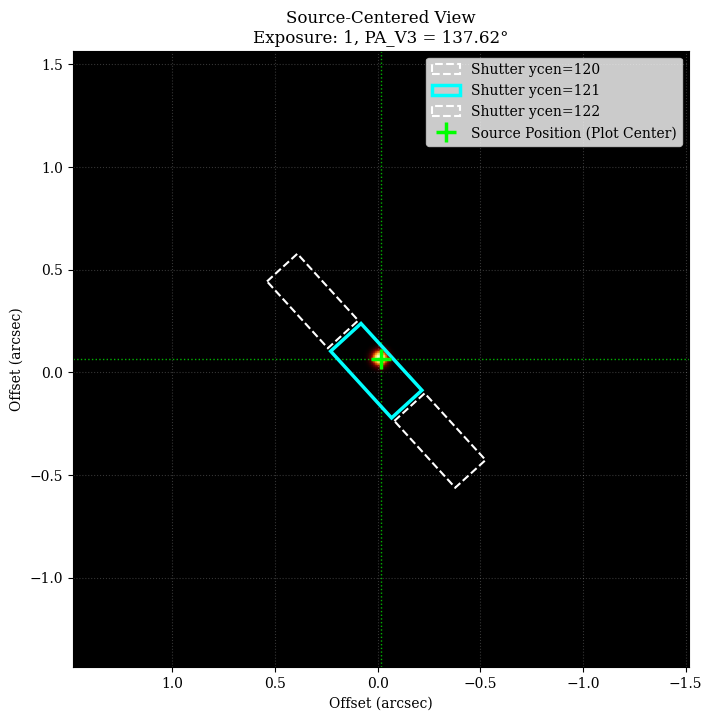

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- 1. 定义 NIRSpec MSA 快门常量 ---
SHUTTER_WIDTH_ARCSEC = 0.20  # 色散方向
SHUTTER_HEIGHT_ARCSEC = 0.46 # 交叉色散方向

# --- 2. 您的观测数据 ---
obs_data = [
    ('jw04446001001_03101_00001_nrs1_f100lp_g140m_raw.42.4446_511.fits', 1692, 34, 9.83316762, -10.10036492, 15.39073173, 0.1034026, 0.16797236, 511, '4446_511', 171.8278747, 42.48567156, 0.05599999, -0.03799999, '1x1', 44081, 42, -2.2, 2.2, 4, 281, 121, 357, 1692, 211, 34, 'NRS1', 'G140M', 'F100LP', 'jw04446001001_01_msa.fits', 1, 1, 1458.889, 5, 20, 1, 'NRSIRS2', 60056.77958195, 42.4474189, 137.61726042, 172.00791935, '3-SHUTTER-SLITLET', 1, 'NONE', 3, -38.60351664, -2.59930635),
    ('jw04446001001_03101_00002_nrs1_f100lp_g140m_raw.42.4446_511.fits', 1692, 34, 9.83316762, -10.10036492, 20.50640663, 0.1034026, 0.16797236, 511, '4446_511', 171.8278747, 42.48567156, 0.04699999, -0.05000001, 'x11', 43716, 42, -1.05, 3.35, 4, 281, 120, 357, 1692, 211, 34, 'NRS1', 'G140M', 'F100LP', 'jw04446001001_01_msa.fits', 1, 1, 1458.889, 5, 20, 1, 'NRSIRS2', 60056.79781822, 42.44740331, 137.61730611, 172.00811756, '3-SHUTTER-SLITLET', 2, 'NONE', 3, -38.60350931, -2.07033228),
    ('jw04446001001_03101_00003_nrs1_f100lp_g140m_raw.42.4446_511.fits', 1692, 34, 9.83316762, -10.10036492, 10.2746088, 0.1034026, 0.16797236, 511, '4446_511', 171.8278747, 42.48567156, 0.06599998, -0.02599999, '11x', 44446, 42, -3.35, 1.05, 4, 281, 122, 357, 1692, 211, 34, 'NRS1', 'G140M', 'F100LP', 'jw04446001001_01_msa.fits', 1, 1, 1458.889, 5, 20, 1, 'NRSIRS2', 60056.8158856, 42.44743482, 137.61709658, 172.00772145, '3-SHUTTER-SLITLET', 3, 'NONE', 3, -38.60352677, -3.12832674)
]

# --- 3. 选择要绘制的曝光 ---
exposure_to_plot = 0
selected_data = obs_data[exposure_to_plot]

# 提取相关信息
source_xpos = selected_data[12]
source_ypos = selected_data[13]
active_shutter_ycen = selected_data[21]
pa_v3 = selected_data[39]

# --- 4. 关键步骤：首先计算源的最终位置 ---
# 这将成为我们绘图的中心
angle_rad = np.deg2rad(pa_v3)
cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

# 计算活动快门在slitlet-center坐标系中的中心位置
active_shutter_local_y_center = (active_shutter_ycen - 121) * SHUTTER_HEIGHT_ARCSEC
active_shutter_local_center = np.array([0, active_shutter_local_y_center])

# 旋转活动快门的中心
rotated_shutter_center_x = active_shutter_local_center[0] * cos_a - active_shutter_local_center[1] * sin_a
rotated_shutter_center_y = active_shutter_local_center[0] * sin_a + active_shutter_local_center[1] * cos_a

# 将源的偏移量添加到旋转后的快门中心，得到源的最终绝对坐标
final_source_x = rotated_shutter_center_x + (source_xpos * cos_a - source_ypos * sin_a)
final_source_y = rotated_shutter_center_y + (source_xpos * sin_a + source_ypos * cos_a)

# --- 5. 设置绘图 ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- 6. 绘制以源为中心的PSF ---
# 定义PSF图像在屏幕上显示的角秒尺寸
psf_display_width = 3.0  # arcsec
psf_half_width = psf_display_width / 2.0

# 创建一个高斯函数作为PSF的模拟
x, y = np.mgrid[-psf_half_width:psf_half_width:.01, -psf_half_width:psf_half_width:.01]
pos = np.dstack((x, y))
# FWHM ~ 0.06" for JWST, so sigma ~ 0.025
rv = np.exp(-((pos[:, :, 0]**2 + pos[:, :, 1]**2) / (2.0 * 0.025**2)))

# 使用 extent 参数将 PSF 图像精确地放置在以 final_source 为中心的位置
ax.imshow(rv,
          extent=[final_source_x - psf_half_width, final_source_x + psf_half_width,
                  final_source_y - psf_half_width, final_source_y + psf_half_width],
          origin='lower',
          cmap='afmhot', # 使用更像PSF的颜色映射
          zorder=0) # 确保PSF在最底层

# --- 7. 绘制 Slitlet ---
# 这部分代码与之前相同，因为它在绝对坐标系中绘制slitlet，现在该坐标系的中心就是源
transform = plt.matplotlib.transforms.Affine2D().rotate_deg(pa_v3) + ax.transData
shutter_ycens = [120, 121, 122]
for ycen in shutter_ycens:
    local_y_center = (ycen - 121) * SHUTTER_HEIGHT_ARCSEC
    local_bottom_left_x = -SHUTTER_WIDTH_ARCSEC / 2
    local_bottom_left_y = local_y_center - SHUTTER_HEIGHT_ARCSEC / 2

    is_active = (ycen == active_shutter_ycen)
    edge_color = 'cyan' if is_active else 'white'
    line_style = '-' if is_active else '--'
    line_width = 2.5 if is_active else 1.5

    rect = patches.Rectangle(
        (local_bottom_left_x, local_bottom_left_y),
        SHUTTER_WIDTH_ARCSEC,
        SHUTTER_HEIGHT_ARCSEC-0.02,
        linewidth=line_width,
        linestyle=line_style,
        edgecolor=edge_color,
        facecolor='none',
        transform=transform,
        label=f'Shutter ycen={ycen}',
        zorder=5 # 确保slitlet在PSF之上
    )
    ax.add_patch(rect)

# --- 8. 标记源的位置并添加中心十字线 ---
# 十字线可以明确地显示图像中心
ax.axhline(final_source_y, color='lime', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(final_source_x, color='lime', linestyle=':', linewidth=1, alpha=0.7)

# 在中心点放置一个标记
ax.plot(
    final_source_x,
    final_source_y,
    '+',
    color='lime',
    markersize=15,
    mew=2.5,
    label='Source Position (Plot Center)',
    zorder=10 # 确保标记在最顶层
)

# --- 9. 完成绘图 ---
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')
ax.set_title(f"Source-Centered View\nExposure: {exposure_to_plot + 1}, PA_V3 = {pa_v3:.2f}°")
ax.grid(True, linestyle=':', alpha=0.3)

# 创建一个自定义图例
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), loc='upper right')

# 设置绘图范围，使其围绕源为中心
plot_view_radius = 1.5 # arcsec
ax.set_xlim(final_source_x - plot_view_radius, final_source_x + plot_view_radius)
ax.set_ylim(final_source_y - plot_view_radius, final_source_y + plot_view_radius)

# 反转x轴以匹配天空坐标系中东方在左的惯例
ax.invert_xaxis()

plt.show()